In [1]:
import adaptive_latents as al
import adaptive_latents.stimulation.photostimulation as ps
from adaptive_latents import NumpyTimedDataSource, Bubblewrap, AnimationManager, BWRun
from adaptive_latents.transforms.proSVD import proSVD
from adaptive_latents.transforms.utils import prosvd_data, clip
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform

In [2]:
# Specify the paths to the files
stim_file_path = '../workspace/datasets/fish/output_020424_ds1/stimmed.txt'
C_file_path = '../workspace/datasets/fish/output_020424_ds1/analysis_proc_C.txt'
photo_file_path = '../workspace/datasets/fish/output_020424_ds1/photostims.npy'

# Load the files
v_stim = np.loadtxt(stim_file_path) 
"""1st entry: frame number,
2nd entry: ignore,
3rd entry: angle of motion L,
4th entry: angle of motion R,
5th entry: timestamp,"""
C = np.loadtxt(C_file_path)#
"""Calcium imaging. 
1st entry is neuron ID,
2nd is time (frame)"""
photostim = np.load(photo_file_path)
"""1st entry: frame number,
2nd entry: counter of stims,
3rd entry: neuron ID,
4th entry: position X of neuron,
5th entry: position Y of neuron,"""

# extra note: Fs= 2.3 Hz

'1st entry: frame number,\n2nd entry: counter of stims,\n3rd entry: neuron ID,\n4th entry: position X of neuron,\n5th entry: position Y of neuron,'

## Absolute distance between photostims

In [3]:
C_visual= C[:, :1114]
C_photostim = C[:, 1114:]

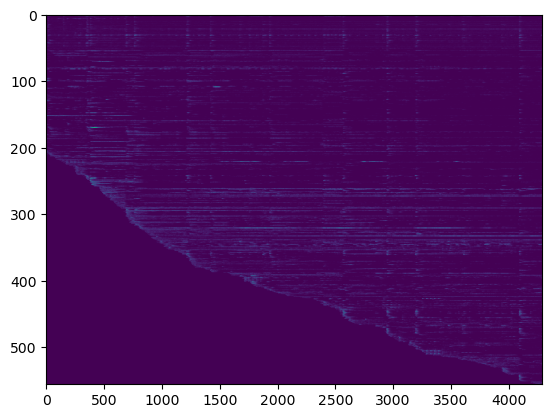

In [4]:
plt.imshow(C_photostim, aspect='auto')

In [5]:
#Dimensionality reduction 
pro = proSVD(6, centering=True) # like the PCA() step
pro.run_on(C_visual) # like the fit_transform step
small_C=pro.project(C_photostim).T # like the transform step

In [6]:
small_C.shape, C.shape, photostim.shape , C_photostim.shape

((4291, 6), (556, 5405), (126, 5), (556, 4291))

In [7]:
def rank_neurons(stim, C, photostim):
    # Create DataFrame for stim
    stim_columns = ['frame_number', 'ignore', 'angle_of_motion_L', 'angle_of_motion_R', 'timestamp']
    stim_df = pd.DataFrame(stim, columns=stim_columns)

    # Create DataFrame for C, where each column after the first represents a neuron
    neuron_ids = [f'neuron_{i}' for i in range(C.shape[0])]
    time_points = [f'frame_{i}' for i in range(C.shape[1])]
    C_df = pd.DataFrame(C.T, columns=neuron_ids, index=time_points)

    # Create DataFrame for photostim
    photostim_columns = ['frame_number', 'stim_counter', 'neuron_ID', 'position_X', 'position_Y']
    photostim_df = pd.DataFrame(photostim, columns=photostim_columns)

    # Handle neurons with two trials in the data frame: 14 and 98 turn into 15 and 99 in the second trial
    neuron_position_counts = photostim_df.groupby('neuron_ID')['position_X'].count()

    # Filter neurons with more than 6 occurrences
    neurons_with_many_positions = neuron_position_counts[neuron_position_counts > 6].index

    # Filter the DataFrame to include only these neurons
    filtered_neurons_df = photostim_df[photostim_df['neuron_ID'].isin(neurons_with_many_positions)]

    # Function to modify the neuron ID for the second group of 5 occurrences
    def modify_neuron_ids(df):
        modified_ids = df.copy()
        neuron_groups = modified_ids.groupby('neuron_ID')
        
        for neuron_id, group in neuron_groups:
            # Split the group into sets of 5
            for i in range(1, len(group) // 5 + 1):
                start_idx = i * 5
                if start_idx < len(group):
                    modified_ids.loc[group.index[start_idx:start_idx + 5], 'neuron_ID'] = str(int(neuron_id) + 1)
        
        return modified_ids

    # Apply the function to modify the neuron IDs in the original DataFrame
    modified_photostim_df = modify_neuron_ids(photostim_df)
    # Drop the last row by index (we only have one stimulation for the last neuron)
    modified_photostim_df = modified_photostim_df.drop(modified_photostim_df.index[-1])

    # Ensure the frame_number and neuron_ID are of integer type
    modified_photostim_df['frame_number'] = modified_photostim_df['frame_number'].astype(int)
    modified_photostim_df['neuron_ID'] = modified_photostim_df['neuron_ID'].astype(int)

    # Sort the df by 'frame_number'
    modified_photostim_df = modified_photostim_df.sort_values(by='frame_number').reset_index(drop=True)

    return modified_photostim_df

In [8]:
neurons_df=rank_neurons(v_stim, C, photostim) 
index_df=neurons_df.drop_duplicates(subset='neuron_ID', keep='first')
index_df

/tmp/ipykernel_1229996/3812454050.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '15' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  modified_ids.loc[group.index[start_idx:start_idx + 5], 'neuron_ID'] = str(int(neuron_id) + 1)


,frame_number,stim_counter,neuron_ID,position_X,position_Y
0,1114,1.0,109,394.353241,247.732895
5,1284,6.0,98,259.920380,207.710526
10,1454,11.0,87,285.246857,5.215222
15,1624,16.0,249,88.201767,228.824142
20,1794,21.0,204,40.095978,138.657837
25,1969,26.0,18,267.881104,390.008789
30,2142,31.0,246,162.987305,362.435669
35,2310,36.0,353,357.254181,241.590988
40,2484,41.0,247,220.739487,392.086304
45,2655,46.0,387,72.179871,359.769836


In [62]:
#Calculating the distance matrix

# Extract and adjust indices based on 'frame_number' from index_df
indices = index_df['frame_number'].values - 1114

# Convert indices to integers
indices = indices.astype(int)

#Select the corresponding rows from C_small
selected_rows = small_C[indices]

#Calculate the pairwise Euclidean distances
distances = pdist(selected_rows, metric='euclidean')
distance_matrix = squareform(distances)

#Convert the distance matrix to a DataFrame with original indices
neuron_indices = index_df['neuron_ID'].values.astype(int)
distance_df = pd.DataFrame(distance_matrix, index=neuron_indices, columns=neuron_indices)

print(distance_df)


           109        98         87         249        204        18   \
109   0.000000  23.737977  25.457091  22.796073  22.092202  27.784749   
98   23.737977   0.000000   5.057709   5.582129   4.973124   5.791890   
87   25.457091   5.057709   0.000000   4.434617   4.346353   7.637862   
249  22.796073   5.582129   4.434617   0.000000   3.126652   7.792544   
204  22.092202   4.973124   4.346353   3.126652   0.000000   8.834732   
18   27.784749   5.791890   7.637862   7.792544   8.834732   0.000000   
246  27.502873   5.315017   6.912541   7.267732   8.018536   2.312940   
353  28.897338   7.881473   9.002968   9.266748   9.049687   6.813658   
247  27.681025   5.279280   7.096978   7.346360   8.239765   2.299564   
387  27.470187   4.437694   7.177969   8.262443   8.700583   3.893749   
166  29.218377   7.700204   8.066571   8.716693   8.926448   6.410310   
132  25.628607   4.708108   6.298534   5.702427   6.394448   5.554404   
14   27.147420   5.223838   7.743093   8.170289   8

In [66]:
# Extract distances from one index to the next
sequential_distances = []
for i in range(len(neuron_indices) - 1):
    index1 = neuron_indices[i]
    index2 = neuron_indices[i + 1]
    distance = distance_df.loc[index1, index2]
    sequential_distances.append((index1, index2, distance))

# Step 6: Convert to DataFrame
sequential_distances_df = pd.DataFrame(sequential_distances, columns=['Index1', 'Index2', 'Distance'])

#Sort by distance 
sequential_distances = sequential_distances_df.nlargest(24, 'Distance')

print(sequential_distances)

    Index1  Index2   Distance
0      109      98  23.737977
23     103      82   9.963313
4      204      18   8.834732
9      387     166   6.505986
13      31     156   6.330885
12      14      31   5.767505
7      353     247   5.246185
6      246     353   5.136901
16      15     123   5.103556
1       98      87   5.057709
10     166     132   4.562219
11     132      14   4.474078
2       87     249   4.434617
14     156     294   4.366425
15     294      15   3.891005
19     411      28   3.266179
3      249     204   3.126652
8      247     387   3.048285
17     123     452   2.748494
18     452     411   2.663700
5       18     246   2.312940
22     330     103   1.714872
20      28      99   1.312775
21      99     330   1.263782


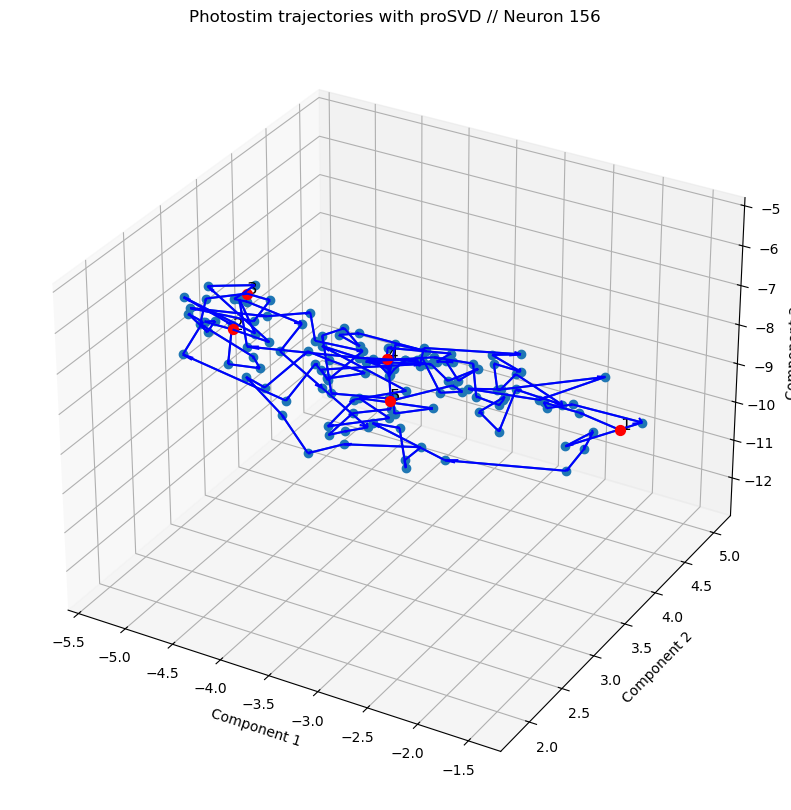

In [77]:
##REMEMBER THIS IS IN 3D, AND THE RANKING IS IN 6D
ps.plot_photostim(156,'proSVD',C, photostim, neurons_df)


## Path distances between photostims

In [74]:
# Subtract 1114 from frame_number using .loc
index_df.loc[:, 'frame_number'] = index_df['frame_number'] - 1114

# Reset the index of index_df to ensure integer indexing
index_df.reset_index(drop=True, inplace=True)

# Function to calculate the sum of Euclidean distances in 6D
def calculate_sum_of_distances(small_C, index_df):
    results = []

    # Iterate over the ranges defined by frame_number in index_df
    for i in range(len(index_df) - 1):
        start_frame = index_df.loc[i, 'frame_number']
        end_frame = index_df.loc[i + 1, 'frame_number']
        neuron_id = index_df.loc[i, 'neuron_ID']

        # Extract the rows of small_C between start_frame and end_frame
        subset = small_C[start_frame:end_frame, :]

        # Calculate the pairwise Euclidean distances
        distances = pdist(subset, metric='euclidean')

        # Sum the distances
        sum_distances = np.sum(distances)
        results.append({'neuron_ID': neuron_id, 'sum_distances': sum_distances})

    return results

# Calculate the sum of distances for each jump in frame_number
sum_of_distances = calculate_sum_of_distances(small_C, index_df)

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(sum_of_distances)

# Print the results
print(results_df)


    neuron_ID  sum_distances
0         109      20.874737
1          98  120226.958761
2          87   62811.096893
3         249  110172.213753
4         204   58225.955404
5          18  100078.584529
6         246   36013.558066
7         353   42312.687642
8         247   93334.149715
9         387   65872.590179
10        166   53571.768482
11        132   44152.261015
12         14   52833.403887
13         31   45526.226101
14        156   28812.189473
15        294   41045.141220
16         15   55639.494025
17        123   31878.770203
18        452   61787.322215
19        411   63382.918459
20         28   24760.182965
21         99   23445.645166
22        330   25497.863413
23        103   26761.265611


In [79]:
# Rank the results based on the sum of distances
results_df['rank'] = results_df['sum_distances'].rank(ascending=False, method='min')

# Sort the DataFrame by rank
results_df.sort_values(by='rank', inplace=True)

results_df

,neuron_ID,sum_distances,rank
1,98,120226.958761,1.0
3,249,110172.213753,2.0
5,18,100078.584529,3.0
8,247,93334.149715,4.0
9,387,65872.590179,5.0
19,411,63382.918459,6.0
2,87,62811.096893,7.0
18,452,61787.322215,8.0
4,204,58225.955404,9.0
16,15,55639.494025,10.0


## Distance off(from?)-manifold

We want to get the "distance from manifold" for the photostimulations. From ooutputs of proSVD we do:
Display equation: $$X\perp = X - Q\tilde{X}$$

In [22]:
#Xtilde = smallC, Q = pro.Q, X = C_photostim
C_small_orthogonal = C_photostim - pro.Q @ small_C.T
#C_photostim.shape,  pro.Q.shape , small_C.T.shape

Note 1: To take percenatjes from _small_orth we would need to normalize all the way from C, because C_small_orth only tell you what amount of 'info' was 'not taken' in that input of the matrix
Note 2: Q.T takes you down dimensions when projecting, Q take syou up to the original space